# Machine Learning Approach for Identifying Protein Binding Sites

# **Own Database**
Creamos nuestra propia database con un LLM de proteins donde obtenemos casi 1000 features para cada aminoacido de cada proteina basandonos en su posición, evolución... etc.

## **Installing libraries**

In [9]:
!pip install sklearn scikit-learn ipywidgets 

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [7]:
!pip install lazypredict seaborn imbalanced-learn rdkit 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 62.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 126.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 814.0/814.0 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 19.0 MB/s eta 0:00:00


## **Importing libraries**

Before beginning, we will import all the required libraries and modules.

In [10]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, PandasTools, Descriptors, Crippen, Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import Counter
from sklearn.model_selection import (
    cross_validate, cross_val_predict, StratifiedGroupKFold
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report, matthews_corrcoef,
    precision_recall_curve, PrecisionRecallDisplay, precision_score, recall_score,
    accuracy_score, make_scorer, average_precision_score, brier_score_loss,
    RocCurveDisplay, auc, average_precision_score, balanced_accuracy_score,
)
from imblearn.metrics import specificity_score
from sklearn.semi_supervised import LabelSpreading
from lazypredict.Supervised import LazyClassifier
from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV
import collections
import lightgbm as lgb
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import lazypredict
import pickle

In [11]:
import tarfile
import pyarrow.parquet as pq
import pyarrow as pa
import pandas as pd
import io

with tarfile.open('00_Dataset/model_dataset.tar.gz', 'r:gz') as tar:
    member = tar.getmember('model_dataset.parquet')
    f = tar.extractfile(member)
    data = io.BytesIO(f.read())  # carga en RAM, no en disco

parquet_file = pq.ParquetFile(data)
chunks = []

for batch in parquet_file.iter_batches(batch_size=50_000):
    chunk = batch.to_pandas().sample(frac=0.10, random_state=42)
    chunks.append(chunk)

muestra = pd.concat(chunks)
muestra.to_parquet('muestra.parquet')
print(f"Muestra guardada: {len(muestra)} filas")

FileNotFoundError: [Errno 2] No such file or directory: '00_Dataset/model_dataset.tar.gz'

In [12]:
df = pd.read_parquet('muestra.parquet')
print(df.shape)
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'muestra.parquet'

# **Preparing X and Y data matrices**

The x variable contains all the information used to predict the y variable, while the y variable represents the original outcome that we aim to evaluate.

### **X data matrices**


In [5]:
x = df.drop(columns=['pdb_id', 'receptor_chain', 'ligand_id', 'position', 'residue', 'isbinding'])
x.head()

,esm_0,esm_1,esm_2,esm_3,esm_4,esm_5,esm_6,esm_7,esm_8,esm_9,...,esm_950,esm_951,esm_952,esm_953,esm_954,esm_955,esm_956,esm_957,esm_958,esm_959
33553,0.01,-0.03,-0.04,-0.02,-0.03,0.06,-0.03,-0.01,-0.01,0.03,...,0.00,-0.01,0.01,0.00,-0.01,-0.05,0.01,-0.01,-0.02,0.01
9427,0.04,0.02,0.01,-0.02,0.10,-0.00,-0.01,0.05,-0.02,0.05,...,0.11,0.04,0.02,-0.02,0.01,-0.06,-0.05,-0.02,-0.07,0.01
199,-0.00,-0.04,0.04,-0.03,0.00,-0.01,0.02,0.01,0.03,0.04,...,0.02,0.03,0.01,0.04,-0.01,0.01,-0.03,0.02,-0.03,-0.03
12447,0.00,-0.02,0.01,-0.03,-0.03,0.00,0.03,0.07,-0.01,0.02,...,0.02,0.01,0.00,0.03,0.03,0.00,-0.03,0.01,-0.01,0.04
39489,-0.04,-0.01,0.05,0.01,-0.05,0.02,-0.06,-0.00,-0.03,0.00,...,-0.03,-0.03,-0.06,-0.04,-0.02,0.01,-0.02,0.03,-0.05,-0.01


### **Y data matrices**


In [6]:
y = df["isbinding"]
y.value_counts()

isbinding
0    491690
1     14027
Name: count, dtype: int64

# **Model comparison**

When comparing different models, lazy classifier serve as a benchmark to evaluate the performance of more complex algorithms.

They are useful in model comparison because:

1. Minimal Training Time: Since they don't require a training phase, lazy classifiers can be quickly tested against other models.

2. Flexibility: Their performance can be sensitive to hyperparameters (like the number of neighbors in k-NN), so they offer insights into how other models might behave with similar settings.

2. Benchmarking: They provide a simple reference point for evaluating how more sophisticated models (e.g., decision trees, neural networks) perform in terms of accuracy, speed, and scalability

### **Lazy Classifier**

First we will remove low variance features because these features do not provide much useful information for the model using Bernoulli distribution which it's useful when we work with binary data.

In [ ]:
print(x.describe())
print(x.dtypes.value_counts())

          esm_0     esm_1     esm_2     esm_3     esm_4     esm_5     esm_6  \
count 505717.00 505717.00 505717.00 505717.00 505717.00 505717.00 505717.00   
mean      -0.00     -0.00      0.00     -0.00     -0.00      0.00     -0.00   
std        0.00      0.00      0.00      0.00      0.00      0.00      0.00   
min       -0.13     -0.19     -0.16     -0.16     -0.16     -0.13     -0.16   
25%       -0.02     -0.02     -0.02     -0.03     -0.02     -0.01     -0.02   
50%       -0.00      0.00      0.00     -0.00     -0.00      0.00     -0.00   
75%        0.02      0.02      0.02      0.02      0.02      0.02      0.01   
max        0.15      0.16      0.14      0.16      0.14      0.17      0.15   

          esm_7     esm_8     esm_9  ...   esm_950   esm_951   esm_952  \
count 505717.00 505717.00 505717.00  ... 505717.00 505717.00 505717.00   
mean      -0.00     -0.00      0.00  ...      0.00     -0.00      0.00   
std        0.00      0.00      0.00  ...      0.00      0.00      

Next, we will split the dataset using StratifiedGroupKFold, which aims to create folds that preserve the class distribution as much as possible while ensuring that groups do not overlap between splits. We will perform cross-validation to evaluate the entire dataset.

In [7]:
sgk = StratifiedGroupKFold(n_splits=5)
sgk.get_n_splits(x, y)

5

In [8]:
groups = df['pdb_id']
for train_idx, test_idx in sgk.split(x, y, groups):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


In [10]:
train_dist_inicial = Counter(y.iloc[train_idx])
test_dist_inicial = Counter(y.iloc[test_idx])
train_dist_inicial

Counter({0: 393355, 1: 11222})

In [11]:

isbinding_proportion_train = train_dist_inicial[1] / (train_dist_inicial[1] + train_dist_inicial[0])
nobinding_proportion_train = train_dist_inicial[0] / (train_dist_inicial[1] + train_dist_inicial[0])
isbinding_proportion_test = test_dist_inicial[1] / (test_dist_inicial[1] + test_dist_inicial[0])
nobinding_proportion_test = test_dist_inicial[0] / (test_dist_inicial[1] + test_dist_inicial[0])

print(f"Initial proportion")
print(f"  Train class distribution: {train_dist_inicial}")
print(f"  Test class distribution: {test_dist_inicial}")
print(f"  Traning class proportion: {isbinding_proportion_train:.2f} active to {nobinding_proportion_train:.2f} inactive")
print(f"  Test class proportion: {isbinding_proportion_test:.2f} active to {nobinding_proportion_test:.2f} inactive")

Initial proportion
  Train class distribution: Counter({0: 393355, 1: 11222})
  Test class distribution: Counter({0: 98335, 1: 2805})
  Traning class proportion: 0.03 active to 0.97 inactive
  Test class proportion: 0.03 active to 0.97 inactive


In [ ]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((404577, 960), (101140, 960), (404577,), (101140,))

In [ ]:
comparation = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
models,predictions = comparation.fit(x_train, x_test, y_train, y_test)

  0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
# Performance table of the training set (80% subset)
predictions

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
GaussianNB,0.77,0.74,None,0.85,0.02
LabelSpreading,0.98,0.64,None,0.98,0.63
LabelPropagation,0.98,0.64,None,0.98,0.55
QuadraticDiscriminantAnalysis,0.88,0.62,None,0.92,0.02
AdaBoostClassifier,0.98,0.50,None,0.98,0.19
PassiveAggressiveClassifier,0.98,0.50,None,0.98,0.02
CalibratedClassifierCV,0.98,0.50,None,0.98,0.08
DummyClassifier,0.98,0.50,None,0.98,0.01
RidgeClassifier,0.98,0.50,None,0.98,0.02


In [ ]:
# Performance table of the test set (20% subset)
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
GaussianNB,0.77,0.74,None,0.85,0.02
LabelSpreading,0.98,0.64,None,0.98,0.63
LabelPropagation,0.98,0.64,None,0.98,0.55
QuadraticDiscriminantAnalysis,0.88,0.62,None,0.92,0.02
AdaBoostClassifier,0.98,0.50,None,0.98,0.19
PassiveAggressiveClassifier,0.98,0.50,None,0.98,0.02
CalibratedClassifierCV,0.98,0.50,None,0.98,0.08
DummyClassifier,0.98,0.50,None,0.98,0.01
RidgeClassifier,0.98,0.50,None,0.98,0.02


When we use a lazy classifier, we generally trust model dataframe because it reflects how well the model performs on a separate dataset that it has never seen before, while prediction reflects how well the model performs on the data it was trained on. This is why the results from the model dataframe suggest that the LabelSpreading seem to perform better. Now, we will try different models to see which one works best. Additionally, we will use the RandomForestRegressor as well, because it is a standard model that usually performs well.

# **Model deployment**

### **RandomForestClassifier**

In [ ]:
model1 = RandomForestClassifier(random_state=42)

Cross-validation is a machine learning technique used to assess a model’s performance on unseen data. It involves splitting the dataset into multiple folds, training the model on some folds while using one for validation, and repeating the process multiple times. K-Fold Cross Validation, a common approach, divides the data into k subsets, iterating k times with a different fold for testing each time. This ensures a more reliable performance estimate and improves model generalization.

In [ ]:
specificity_scorer = make_scorer(specificity_score, average='weighted')

In [ ]:
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'roc_auc': 'roc_auc',
    'matthews_corrcoef': 'matthews_corrcoef',
    'f1_weighted': 'f1_weighted',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'specificity_weighted': specificity_scorer
}

In [ ]:
num_folds = 5
StraGroupKFold = StratifiedGroupKFold(n_splits=num_folds)
cross_val_results = cross_validate(model1, x, y, cv=StraGroupKFold, scoring= scoring, groups= groups_int)
cross_val_results

{'fit_time': array([0.15082812, 0.15415907, 0.15741324, 0.15482593, 0.14649725]),
 'score_time': array([0.0328567 , 0.03661156, 0.03506231, 0.03246689, 0.03141761]),
 'test_balanced_accuracy': array([0.58919088, 0.64885321, 0.54373436, 0.49942595, 0.49712974]),
 'test_roc_auc': array([0.921587  , 0.93864679, 0.8212573 , 0.84328358, 0.78641135]),
 'test_matthews_corrcoef': array([ 0.26367834,  0.41981857,  0.14447175, -0.00638209, -0.00955649]),
 'test_f1_weighted': array([0.98390333, 0.98810982, 0.98187163, 0.94660963, 0.9735015 ]),
 'test_precision_weighted': array([0.98242244, 0.98757359, 0.97942201, 0.93034305, 0.96852337]),
 'test_recall_weighted': array([0.98642534, 0.98979592, 0.98527746, 0.96345515, 0.97853107]),
 'test_specificity_weighted': array([0.19195642, 0.3079105 , 0.10219126, 0.03539674, 0.0157284 ])}

In [ ]:
for i, (train_idx, test_idx) in enumerate(StraGroupKFold.split(x, y, groups=groups_int)):
    train_dist = Counter(y.iloc[train_idx])
    test_dist = Counter(y.iloc[test_idx])
    active_proportion_train = train_dist['active'] / (train_dist['active'] + train_dist['inactive'])
    inactive_proportion_train = train_dist['inactive'] / (train_dist['active'] + train_dist['inactive'])
    active_proportion_test = test_dist['active'] / (test_dist['active'] + test_dist['inactive'])
    inactive_proportion_test = test_dist['inactive'] / (test_dist['active'] + test_dist['inactive'])

    print(f"Fold {i+1}:")
    print(f"  Train class distribution: {train_dist}")
    print(f"  Test class distribution: {test_dist}")
    print(f"  Traning class proportion: {active_proportion_train:.2f} active to {inactive_proportion_train:.2f} inactive")
    print(f"  Test class proportion: {active_proportion_test:.2f} active to {inactive_proportion_test:.2f} inactive")

Fold 1:
  Train class distribution: Counter({'inactive': 3486, 'active': 67})
  Test class distribution: Counter({'inactive': 873, 'active': 11})
  Traning class proportion: 0.02 active to 0.98 inactive
  Test class proportion: 0.01 active to 0.99 inactive
Fold 2:
  Train class distribution: Counter({'inactive': 3487, 'active': 68})
  Test class distribution: Counter({'inactive': 872, 'active': 10})
  Traning class proportion: 0.02 active to 0.98 inactive
  Test class proportion: 0.01 active to 0.99 inactive
Fold 3:
  Train class distribution: Counter({'inactive': 3487, 'active': 67})
  Test class distribution: Counter({'inactive': 872, 'active': 11})
  Traning class proportion: 0.02 active to 0.98 inactive
  Test class proportion: 0.01 active to 0.99 inactive
Fold 4:
  Train class distribution: Counter({'inactive': 3488, 'active': 46})
  Test class distribution: Counter({'inactive': 871, 'active': 32})
  Traning class proportion: 0.01 active to 0.99 inactive
  Test class proportion: 0

In [ ]:
result_model1_1 = cross_val_results["test_balanced_accuracy"].mean()
result_model1_2 = cross_val_results["test_roc_auc"].mean()
result_model1_3 = cross_val_results["test_matthews_corrcoef"].mean()
result_model1_4 = cross_val_results["test_f1_weighted"].mean()
result_model1_5 = cross_val_results["test_precision_weighted"].mean()
result_model1_6 = cross_val_results["test_recall_weighted"].mean()
result_model1_7 = cross_val_results["test_specificity_weighted"].mean()
results_model1 = [result_model1_1, result_model1_2, result_model1_3, result_model1_4, result_model1_5, result_model1_6, result_model1_7]

In [ ]:
print(f'Mean Balanced_accuracy: {result_model1_1}')
print(f'Mean Roc_auc: {result_model1_2}')
print(f'Mean Matthews_corrcoef: {result_model1_3}')
print(f'Mean F1_weighted: {result_model1_4}')
print(f'Mean Precision_weighted: {result_model1_5}')
print(f'Mean Recall_weighted: {result_model1_6}')
print(f'Mean Specificity_weighted: {result_model1_7}')


Mean Balanced_accuracy: 0.5556668267902001
Mean Roc_auc: 0.8622372045467837
Mean Matthews_corrcoef: 0.16240601727488346
Mean F1_weighted: 0.9747991842583449
Mean Precision_weighted: 0.969656892772939
Mean Recall_weighted: 0.980696988775102
Mean Specificity_weighted: 0.13063666480529817


In [ ]:
df_model_1 = pd.DataFrame(results_model1)
df_model_1 = df_model_1.transpose()
df_model_1.columns = ['balanced_accuracy', 'roc_auc', 'matthews_corrcoef', 'f1_weighted', 'precision_weighted', 'recall_weighted', 'specificity_weighted']
df_model_1

,balanced_accuracy,roc_auc,matthews_corrcoef,f1_weighted,precision_weighted,recall_weighted,specificity_weighted
0,0.56,0.86,0.16,0.97,0.97,0.98,0.13


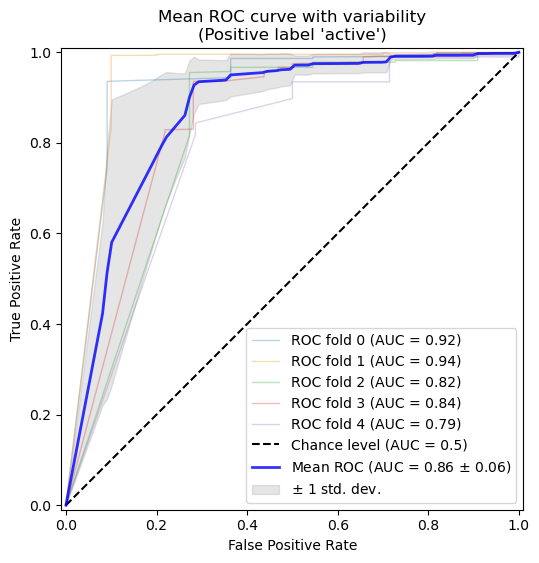

In [ ]:
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(6, 6))
for fold, (train, test) in enumerate(StraGroupKFold.split(x, y, groups=groups_int)):
    model1.fit(x[train], y.iloc[train])
    viz = RocCurveDisplay.from_estimator(
        model1,
        x[test],
        y.iloc[test],
        name=f"ROC fold {fold}",
        alpha=0.3,
        lw=1,
        ax=ax,
        plot_chance_level=(fold == num_folds - 1),
    )
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(
    mean_fpr,
    mean_tpr,
    color="b",
    label=r"Mean ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)

ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title=f"Mean ROC curve with variability\n(Positive label 'active')",
)
ax.legend(loc="lower right")
plt.show()

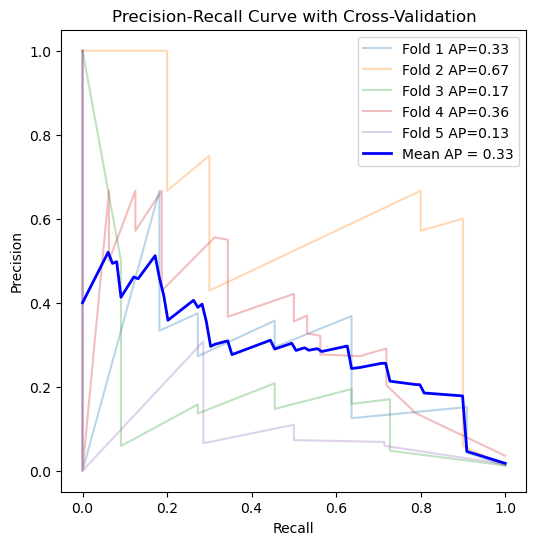

In [ ]:
precisions = []
recalls = []
aps = []
mean_recall = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(6, 6))

for fold, (train_idx, test_idx) in enumerate(StraGroupKFold.split(x, y, groups=groups_int)):
    model1.fit(x[train_idx], y.iloc[train_idx])

    y_pred_prob = model1.predict_proba(x[test_idx])[:, 0]

    precision, recall, _ = precision_recall_curve(y.iloc[test_idx], y_pred_prob, pos_label= "active")
    ap = average_precision_score(y.iloc[test_idx], y_pred_prob, pos_label= "active")

    interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])

    precisions.append(interp_precision)
    aps.append(ap)

    ax.plot(recall, precision, alpha=0.3, label=f'Fold {fold+1} AP={ap:.2f}')

mean_precision = np.mean(precisions, axis=0)
mean_ap = np.mean(aps)

ax.plot(mean_recall, mean_precision, color='b', lw=2, label=f'Mean AP = {mean_ap:.2f}')
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve with Cross-Validation")
ax.legend()
plt.show()

In [ ]:
pr_auc_values_1 = pd.DataFrame(data = [0.28], index= ['RandomForestClassifier (g.s)'])

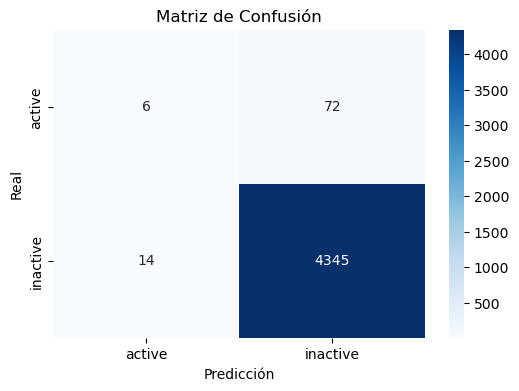

In [ ]:
y_prediction = cross_val_predict(model1, x, y, cv=StraGroupKFold, groups=groups_int)

cm_1 = confusion_matrix(y, y_prediction)

plt.figure(figsize=(6,4))
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

### **ExtraTreesClassifier**

In [ ]:
model2 = ExtraTreesClassifier(n_estimators=100, random_state=0)

In [ ]:
specificity_scorer = make_scorer(specificity_score, average='weighted')

In [ ]:
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'roc_auc': 'roc_auc',
    'matthews_corrcoef': 'matthews_corrcoef',
    'f1_weighted': 'f1_weighted',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'specificity_weighted': specificity_scorer
}

In [ ]:
num_folds = 5
StraGroupKFold2 = StratifiedGroupKFold(n_splits=num_folds)
cross_val_results_2 = cross_validate(model2, x, y, cv=StraGroupKFold2, scoring= scoring, groups= groups_int)
cross_val_results_2

{'fit_time': array([0.14734507, 0.13806748, 0.14036989, 0.13879085, 0.14275193]),
 'score_time': array([0.03381681, 0.03209329, 0.03598595, 0.03336883, 0.03240585]),
 'test_balanced_accuracy': array([0.58919088, 0.64827982, 0.54144078, 0.53067595, 0.49770379]),
 'test_roc_auc': array([0.92793919, 0.94300459, 0.74061718, 0.69670278, 0.74073315]),
 'test_matthews_corrcoef': array([ 0.26367834,  0.38198174,  0.0970205 ,  0.19711976, -0.00854274]),
 'test_f1_weighted': array([0.98390333, 0.98725787, 0.97924404, 0.95172863, 0.97406934]),
 'test_precision_weighted': array([0.98242244, 0.9864308 , 0.97781346, 0.95603544, 0.96854114]),
 'test_recall_weighted': array([0.98642534, 0.98866213, 0.98074745, 0.96566999, 0.97966102]),
 'test_specificity_weighted': array([0.19195642, 0.3078975 , 0.10213412, 0.09568191, 0.01574656])}

In [ ]:
result_model2_1 = cross_val_results_2["test_balanced_accuracy"].mean()
result_model2_2 = cross_val_results_2["test_roc_auc"].mean()
result_model2_3 = cross_val_results_2["test_matthews_corrcoef"].mean()
result_model2_4 = cross_val_results_2["test_f1_weighted"].mean()
result_model2_5 = cross_val_results_2["test_precision_weighted"].mean()
result_model2_6 = cross_val_results_2["test_recall_weighted"].mean()
result_model2_7 = cross_val_results_2["test_specificity_weighted"].mean()

results_model2 = [result_model2_1, result_model2_2, result_model2_3, result_model2_4, result_model2_5, result_model2_6, result_model2_7]

In [ ]:
print(f'Mean Balanced_accuracy: {result_model2_1}')
print(f'Mean Roc_auc: {result_model2_2}')
print(f'Mean Matthews_corrcoef: {result_model2_3}')
print(f'Mean F1_weighted: {result_model2_4}')
print(f'Mean Precision_weighted: {result_model2_5}')
print(f'Mean Recall_weighted: {result_model2_6}')
print(f'Mean Specificity_weighted: {result_model2_7}')

Mean Balanced_accuracy: 0.5614582428573589
Mean Roc_auc: 0.8097993770833938
Mean Matthews_corrcoef: 0.1862515213330504
Mean F1_weighted: 0.9752406451014828
Mean Precision_weighted: 0.9742486546524551
Mean Recall_weighted: 0.980233185725875
Mean Specificity_weighted: 0.14268329998884283


In [ ]:
df_model_2 = pd.DataFrame(results_model2)
df_model_2 = df_model_2.transpose()
df_model_2.columns = ['balanced_accuracy', 'roc_auc', 'matthews_corrcoef', 'f1_weighted', 'precision_weighted', 'recall_weighted', 'specificity_weighted']
df_model_2

,balanced_accuracy,roc_auc,matthews_corrcoef,f1_weighted,precision_weighted,recall_weighted,specificity_weighted
0,0.56,0.81,0.19,0.98,0.97,0.98,0.14


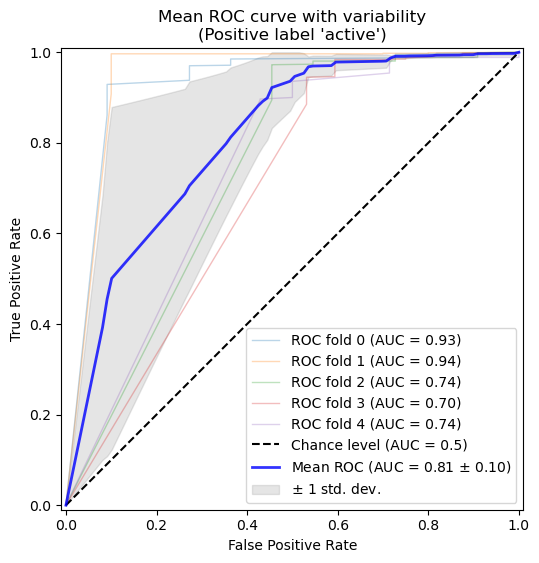

In [ ]:
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(6, 6))
for fold, (train, test) in enumerate(StraGroupKFold2.split(x, y, groups=groups_int)):
    model2.fit(x[train], y.iloc[train])
    viz = RocCurveDisplay.from_estimator(
        model2,
        x[test],
        y.iloc[test],
        name=f"ROC fold {fold}",
        alpha=0.3,
        lw=1,
        ax=ax,
        plot_chance_level=(fold == num_folds - 1),
    )
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(
    mean_fpr,
    mean_tpr,
    color="b",
    label=r"Mean ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)

ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title=f"Mean ROC curve with variability\n(Positive label 'active')",
)
ax.legend(loc="lower right")
plt.show()

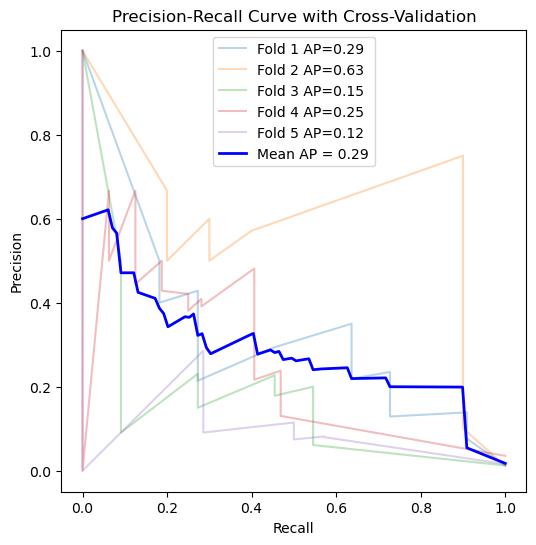

In [ ]:
precisions = []
recalls = []
aps = []
mean_recall = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(6, 6))

for fold, (train_idx, test_idx) in enumerate(StraGroupKFold2.split(x, y, groups=groups_int)):
    model2.fit(x[train_idx], y.iloc[train_idx])

    y_pred_prob = model2.predict_proba(x[test_idx])[:, 0]

    precision, recall, _ = precision_recall_curve(y.iloc[test_idx], y_pred_prob, pos_label= "active")
    ap = average_precision_score(y.iloc[test_idx], y_pred_prob, pos_label= "active")

    interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])

    precisions.append(interp_precision)
    aps.append(ap)

    ax.plot(recall, precision, alpha=0.3, label=f'Fold {fold+1} AP={ap:.2f}')

mean_precision = np.mean(precisions, axis=0)
mean_ap = np.mean(aps)

ax.plot(mean_recall, mean_precision, color='b', lw=2, label=f'Mean AP = {mean_ap:.2f}')
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve with Cross-Validation")
ax.legend()
plt.show()

In [ ]:
pr_auc_values_2 = pd.DataFrame(data = [0.22], index= ['LightGBM (g.s)'])

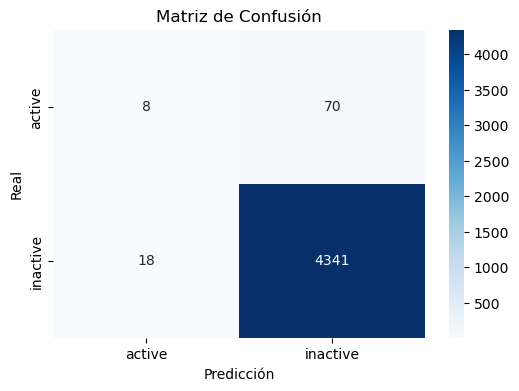

In [ ]:
y_prediction_2 = cross_val_predict(model2, x, y, cv=StraGroupKFold2, groups=groups_int)

cm_2 = confusion_matrix(y, y_prediction_2)

plt.figure(figsize=(6,4))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

### **LabelSpreading**

In [ ]:
model3 = LabelSpreading()

In [ ]:
specificity_scorer = make_scorer(specificity_score, average='weighted')

In [ ]:
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'roc_auc': 'roc_auc',
    'matthews_corrcoef': 'matthews_corrcoef',
    'f1_weighted': 'f1_weighted',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'specificity_weighted': specificity_scorer
}

In [ ]:
num_folds = 5
StraGroupKFold3 = StratifiedGroupKFold(n_splits=num_folds)
cross_val_results_3 = cross_validate(model3, x, y, cv=StraGroupKFold3, scoring= scoring, groups= groups_int)
cross_val_results_3

{'fit_time': array([0.46480751, 0.46672058, 0.46249366, 0.42530155, 0.4458425 ]),
 'score_time': array([0.22080588, 0.20185494, 0.1967144 , 0.20109725, 0.20832539]),
 'test_balanced_accuracy': array([0.71868166, 0.94827982, 0.54258757, 0.49770379, 0.49540758]),
 'test_roc_auc': array([0.74794335, 0.93325688, 0.76178065, 0.83899613, 0.71547482]),
 'test_matthews_corrcoef': array([ 0.32604231,  0.81938342,  0.11499847, -0.01278545, -0.01210877]),
 'test_f1_weighted': array([0.9796312 , 0.99566839, 0.98053857, 0.94494435, 0.97179408]),
 'test_precision_weighted': array([0.98380939, 0.99602914, 0.97835826, 0.93022886, 0.96846981]),
 'test_recall_weighted': array([0.97624434, 0.99546485, 0.98301246, 0.96013289, 0.97514124]),
 'test_specificity_weighted': array([0.46111898, 0.90109478, 0.10216269, 0.03527469, 0.01567391])}

In [ ]:
result_model3_1 = cross_val_results_3["test_balanced_accuracy"].mean()
result_model3_2 = cross_val_results_3["test_roc_auc"].mean()
result_model3_3 = cross_val_results_3["test_matthews_corrcoef"].mean()
result_model3_4 = cross_val_results_3["test_f1_weighted"].mean()
result_model3_5 = cross_val_results_3["test_precision_weighted"].mean()
result_model3_6 = cross_val_results_3["test_recall_weighted"].mean()
result_model3_7 = cross_val_results_3["test_specificity_weighted"].mean()
results_model3 = [result_model3_1, result_model3_2, result_model3_3, result_model3_4, result_model3_5, result_model3_6, result_model3_7]

In [ ]:
print(f'Mean Balanced_accuracy: {result_model3_1}')
print(f'Mean Roc_auc: {result_model3_2}')
print(f'Mean Matthews_corrcoef: {result_model3_3}')
print(f'Mean F1_weighted: {result_model3_4}')
print(f'Mean Precision_weighted: {result_model3_5}')
print(f'Mean Recall_weighted: {result_model3_6}')
print(f'Mean Specificity_weighted: {result_model3_7}')

Mean Balanced_accuracy: 0.6405320835435137
Mean Roc_auc: 0.799490366227898
Mean Matthews_corrcoef: 0.24710599470671624
Mean F1_weighted: 0.9745153179344314
Mean Precision_weighted: 0.9713790926241795
Mean Recall_weighted: 0.9779991574667115
Mean Specificity_weighted: 0.3030650096203158


In [ ]:
df_model_3 = pd.DataFrame(results_model3)
df_model_3 = df_model_3.transpose()
df_model_3.columns = ['balanced_accuracy', 'roc_auc', 'matthews_corrcoef', 'f1_weighted', 'precision_weighted', 'recall_weighted', 'specificity_weighted']
df_model_3

,balanced_accuracy,roc_auc,matthews_corrcoef,f1_weighted,precision_weighted,recall_weighted,specificity_weighted
0,0.64,0.80,0.25,0.97,0.97,0.98,0.30


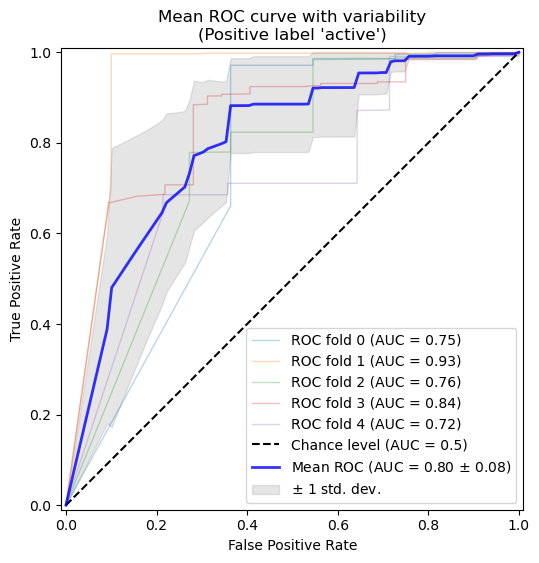

In [ ]:
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(6, 6))
for fold, (train, test) in enumerate(StraGroupKFold3.split(x, y, groups=groups_int)):
    model3.fit(x[train], y.iloc[train])
    viz = RocCurveDisplay.from_estimator(
        model3,
        x[test],
        y.iloc[test],
        name=f"ROC fold {fold}",
        alpha=0.3,
        lw=1,
        ax=ax,
        plot_chance_level=(fold == num_folds - 1),
    )
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(
    mean_fpr,
    mean_tpr,
    color="b",
    label=r"Mean ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)

ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title=f"Mean ROC curve with variability\n(Positive label 'active')",
)
ax.legend(loc="lower right")
plt.show()

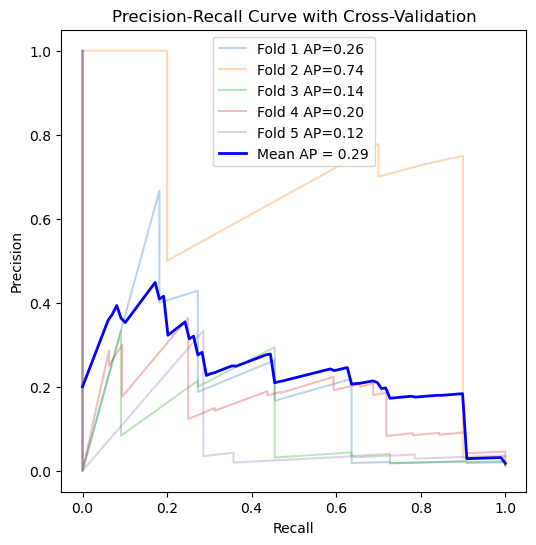

In [ ]:
precisions = []
recalls = []
aps = []
mean_recall = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(6, 6))

for fold, (train_idx, test_idx) in enumerate(StraGroupKFold3.split(x, y, groups=groups_int)):
    model3.fit(x[train_idx], y.iloc[train_idx])

    y_pred_prob = model3.predict_proba(x[test_idx])[:, 0]

    precision, recall, _ = precision_recall_curve(y.iloc[test_idx], y_pred_prob, pos_label= "active")
    ap = average_precision_score(y.iloc[test_idx], y_pred_prob, pos_label= "active")

    interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])

    precisions.append(interp_precision)
    aps.append(ap)

    ax.plot(recall, precision, alpha=0.3, label=f'Fold {fold+1} AP={ap:.2f}')

mean_precision = np.mean(precisions, axis=0)
mean_ap = np.mean(aps)

ax.plot(mean_recall, mean_precision, color='b', lw=2, label=f'Mean AP = {mean_ap:.2f}')
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve with Cross-Validation")
ax.legend()
plt.show()

In [ ]:
pr_auc_values_3 = pd.DataFrame(data = [0.29], index= ['LabelPropagation (g.s)'])

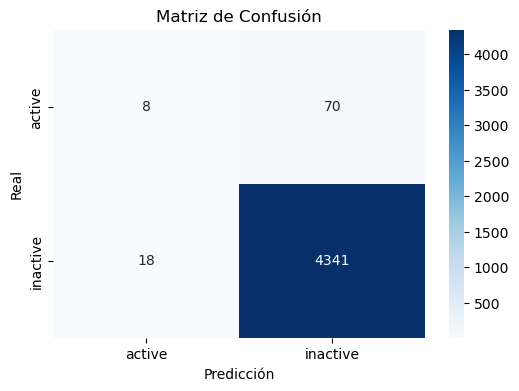

In [ ]:
y_prediction_3 = cross_val_predict(model3, x, y, cv=StraGroupKFold3, groups=groups_int)

cm_3 = confusion_matrix(y, y_prediction_3)

plt.figure(figsize=(6,4))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

# **Overview of model metrics Comparison**

In [ ]:
pr_auc_total_values = pd.concat([pr_auc_values_1, pr_auc_values_2, pr_auc_values_3], axis=0)

df_models_comparison = pd.concat([df_model_1, df_model_2, df_model_3], axis=0)
df_models_comparison.insert(2, "pr_auc", pr_auc_total_values.values)
df_models_comparison.index = ['RandomForestClassifier (g.s)', 'ExtraTreesClassifier (g.s)', 'LabelSpreading (g.s)']
df_models_comparison = df_models_comparison.style.set_properties(**{'text-align': 'center'})
df_models_comparison = df_models_comparison.format(precision=2)
df_models_comparison

,balanced_accuracy,roc_auc,pr_auc,matthews_corrcoef,f1_weighted,precision_weighted,recall_weighted,specificity_weighted
RandomForestClassifier (g.s),0.56,0.86,0.28,0.16,0.97,0.97,0.98,0.13
ExtraTreesClassifier (g.s),0.56,0.81,0.22,0.19,0.98,0.97,0.98,0.14
LabelSpreading (g.s),0.64,0.80,0.29,0.25,0.97,0.97,0.98,0.30


# **Save Model**

In [ ]:
with open('LabelSpreading_rdrp_sarscov2_model_trained.pkl', 'wb') as f:
    pickle.dump(model3, f)
